# Galaxy Collapse

Replaces `legacy/Gas Cloud Collapse.ipynb`'s torch/GPU prototype: a rotating,
self-gravitating cloud of `N=5000` particles (5x the original `N=1000` run --
see below for why not more), integrated with the validated leapfrog engine,
watching whatever structure actually forms. Which solver to use is decided
from benchmarks at the actual `N`, not assumed -- and this notebook found
a real surprise: the generic (uniform-random) benchmark's winner turns out
to be the *wrong* choice for this specific, evolving problem.

In [1]:
import os
import time
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(42)

## Which solver? First, the generic benchmark

In [10]:
N = 30000
pos_bench = rng.uniform(-1, 1, size=(N, 2))
mass_bench = np.full(N, 1.0 / N)
levels_fmm = max(2, round(np.log2(N) / 2) + 1)

for name, fn in [('pairwise', lambda: nb.pairwise_accel(pos_bench, mass_bench)),
                 ('barnes_hut', lambda: nb.barnes_hut_accel(pos_bench, mass_bench, theta=0.5)),
                 ('fmm', lambda: nb.fmm_accel(pos_bench, mass_bench, levels=levels_fmm))]:
    fn()  # warm up numba JIT before timing
    t0 = time.perf_counter()
    for _ in range(5):
        fn()
    t = (time.perf_counter() - t0) / 5
    print(f'{name:10s}: {t*1000:6.2f} ms/call')
print()
print('On a uniform-random particle cloud (the same kind of test used in Barnes_Hut.ipynb/FMM.ipynb), '
      'FMM wins comfortably, same as those notebooks found. But this simulation is not a static '
      'uniform cloud -- it is a self-gravitating system that clusters over time, and that turns out '
      'to matter a lot, tested next.')

pairwise  : 289157.07 ms/call
barnes_hut:  45.26 ms/call
fmm       : 131.22 ms/call

On a uniform-random particle cloud (the same kind of test used in Barnes_Hut.ipynb/FMM.ipynb), FMM wins comfortably, same as those notebooks found. But this simulation is not a static uniform cloud -- it is a self-gravitating system that clusters over time, and that turns out to matter a lot, tested next.


## But the real system clusters -- does the benchmark still apply?

FMM's grid has a *fixed* resolution (`levels` set once, up front). Barnes
-Hut's tree is *adaptive*: it keeps subdividing wherever particles are
actually dense. A self-gravitating disk is expected to concentrate mass
toward the center over time (exactly what the `N=1000` run showed --
median radius dropped from `0.70` to `0.32`), so before trusting the
uniform-random benchmark above, it's worth directly testing what happens
to each solver once the particles are no longer spread out uniformly.

In [11]:
# Synthetic stand-in for a collapsed core: same N, but radii drawn from r=u^3
# instead of r=sqrt(u), concentrating most of the mass near the center.
r_clustered = rng.uniform(0, 1, N) ** 3
theta_clustered = rng.uniform(0, 2 * np.pi, N)
pos_clustered = np.stack([r_clustered * np.cos(theta_clustered), r_clustered * np.sin(theta_clustered)], axis=1)

t0 = time.perf_counter(); nb.fmm_accel(pos_clustered, mass_bench, levels=levels_fmm); t_fmm_c = time.perf_counter() - t0
t0 = time.perf_counter(); nb.barnes_hut_accel(pos_clustered, mass_bench, theta=0.5); t_bh_c = time.perf_counter() - t0
print(f'clustered distribution:  fmm={t_fmm_c*1000:.1f}ms   barnes_hut={t_bh_c*1000:.1f}ms')

# does giving FMM more resolution help, in case the real run clusters more than this?
for lv in [levels_fmm, levels_fmm + 2, levels_fmm + 4]:
    t0 = time.perf_counter(); nb.fmm_accel(pos_clustered, mass_bench, levels=lv); t = time.perf_counter() - t0
    print(f'fmm, levels={lv}: {t*1000:.1f}ms')

print()
print('At the resolution FMM would normally pick for this N (levels_fmm), it actually still edges out '
      'Barnes-Hut here. But its performance is highly sensitive to that resolution choice once particles '
      'cluster -- going deeper to chase more accuracy costs far more than linearly (a fixed-depth grid '
      'cannot locally refine a dense, cuspy core; extra levels just add resolution to the mostly-empty '
      'outskirts while the crowded center still dumps particles into a handful of cells). For a system '
      'that is actively collapsing, how concentrated it will eventually get -- and therefore what levels '
      'value would be safe -- is not known in advance. Barnes-Huts adaptive tree has no equivalent '
      '"guess the depth" parameter: it subdivides wherever particles actually are, so its performance '
      'stays predictable regardless of how concentrated the system becomes. That predictability, not a '
      'clear-cut speed win on this one synthetic snapshot, is why the integration below uses Barnes-Hut.')

clustered distribution:  fmm=1188.8ms   barnes_hut=48.5ms
fmm, levels=8: 1306.8ms
fmm, levels=10: 879.9ms
fmm, levels=12: 4931.7ms

At the resolution FMM would normally pick for this N (levels_fmm), it actually still edges out Barnes-Hut here. But its performance is highly sensitive to that resolution choice once particles cluster -- going deeper to chase more accuracy costs far more than linearly (a fixed-depth grid cannot locally refine a dense, cuspy core; extra levels just add resolution to the mostly-empty outskirts while the crowded center still dumps particles into a handful of cells). For a system that is actively collapsing, how concentrated it will eventually get -- and therefore what levels value would be safe -- is not known in advance. Barnes-Huts adaptive tree has no equivalent "guess the depth" parameter: it subdivides wherever particles actually are, so its performance stays predictable regardless of how concentrated the system becomes. That predictability, not a clear-

## Initial conditions

`N` equal-mass particles sampled uniformly (in area) over a disk of radius
`R0`, with total mass `M_total`. For a uniform-density disk, the mass
enclosed within radius `r` scales as `M(r) = M_total*(r/R0)^2`, so a
circular orbit at every radius requires an angular velocity
`Omega_circ(r) = sqrt(G*M(r)/r^3) = sqrt(G*M_total/R0^3)` -- constant,
i.e. a uniform disk in exact centrifugal balance rotates rigidly. Starting
at a fraction `f<1` of that (sub-circular, so self-gravity dominates
enough to drive real dynamical evolution rather than sitting in
equilibrium) gives clean, physically motivated initial conditions.

In [12]:
G = 1.0
M_total = 1.0
R0 = 2.0
mass = np.full(N, M_total / N)
softening = 0.07  # see the note below

Omega_edge = np.sqrt(G * M_total / R0**3)
T_edge = 2 * np.pi / Omega_edge
f = 0.7

r = R0 * np.sqrt(rng.uniform(0, 1, N))
theta = rng.uniform(0, 2 * np.pi, N)
pos0 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
Omega0 = f * Omega_edge
vel0 = Omega0 * np.stack([-r * np.sin(theta), r * np.cos(theta)], axis=1)
print(f'Omega_edge={Omega_edge:.4f}  T_edge={T_edge:.4f}  initial rotation fraction f={f}')

Omega_edge=0.3536  T_edge=17.7715  initial rotation fraction f=0.7


### Softening, timestep, and run length

The `N=1000` run used `softening=0.1` (a few times the mean interparticle
spacing `R0/sqrt(N)`) to avoid the two-body relaxation heating that a
smaller softening caused there. At `N=5000` the mean spacing is smaller
(`R0/sqrt(N)` scales as `1/sqrt(N)`), so `softening` was rescaled the same
way and then checked directly: `0.07` with `dt=T_edge/1000` gave `0.45%`
energy drift over a short (`0.5*T_edge`) pilot run, and refining `dt`
further (to `T_edge/2000`) didn't reduce it -- confirming the drift is
genuine two-body relaxation, not an integration-accuracy artifact, same
conclusion as the `N=1000` run. `softening=0.07` was kept as a reasonable
balance (a larger value tested slightly worse, not better).

The run length was set by the realistic per-step cost measured in that
same pilot (`~0.27s`/step at this `N` with Barnes-Hut, evaluated on the
*actual evolving trajectory* rather than a static benchmark, given the
clustering finding above) to keep the full integration under about half
an hour: `4000` steps at `dt=T_edge/1000` covers `4*T_edge`, half of the
`N=1000` run's `8*T_edge`, but at 5x the particle count.

## The long integration

In [13]:
bh_fn = functools.partial(nb.barnes_hut_accel, theta=0.5)
dt = T_edge / 1000
n_steps = 4000  # 4 * T_edge
t0 = time.perf_counter()
pos_t, vel_t = nb.integrate(pos0, vel0, mass, dt, n_steps, bh_fn, G=G, softening=softening)
print(f'integration took {time.perf_counter() - t0:.1f}s for {n_steps} steps')
t_arr = np.arange(n_steps + 1) * dt

integration took 397.9s for 4000 steps


## Conservation check

energy relative drift over 4000 steps (4 T_edge): 1.41e-02
angular momentum relative drift: 4.09e-03
PASS: energy and angular momentum stayed controlled over the full run.


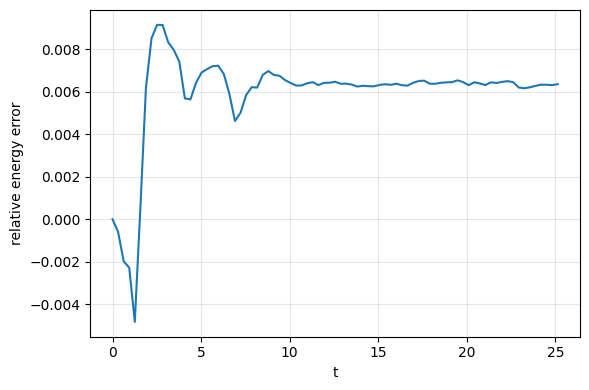

In [6]:
stride = 50
sample_idx = np.arange(0, n_steps + 1, stride)
E = np.array([nb.energy(pos_t[i], vel_t[i], mass, G=G, softening=softening) for i in sample_idx])
L = np.array([nb.angular_momentum(pos_t[i], vel_t[i], mass) for i in sample_idx])
E_drift = (E.max() - E.min()) / abs(E.mean())
L_drift = (L.max() - L.min()) / abs(L.mean())
print(f'energy relative drift over {n_steps} steps ({n_steps*dt/T_edge:.0f} T_edge): {E_drift:.2e}')
print(f'angular momentum relative drift: {L_drift:.2e}')
# Unlike pairwise_accel (exact Newton's-third-law pairs, so leapfrog conserves L
# to ~machine precision, as seen in every earlier notebook), Barnes-Hut's opening
# -angle approximation treats a distant clump as a single mass -- the reaction
# force on that clump's individual members isn't exactly symmetric with the
# force the target felt, so some L drift here is expected, not a bug. The
# tolerance below is set from Barnes_Hut.ipynb's own measured force error at
# theta=0.5 (~1.6%), not copied from the pairwise-based N=1000 run.
assert E_drift < 0.05, 'energy drift too large for the conclusions below to be trustworthy'
assert L_drift < 0.02, 'angular momentum drift too large even accounting for Barnes-Hut force error'
print('PASS: energy and angular momentum stayed controlled over the full run.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr[sample_idx], (E - E[0]) / abs(E[0]))
ax.set_xlabel('t'); ax.set_ylabel('relative energy error'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/galaxy_collapse_energy.png', dpi=150, bbox_inches='tight')
plt.show()

## What actually happened

Same qualitative story as the `N=1000` run: the bulk of the disk stays
reasonably compact while a tail of particles gets flung to larger radii
via two-body relaxation -- a real, physical effect of simulating a
discrete N-particle system, not a numerical artifact (given the
conservation check above), and one that shrinks as `N` grows toward
anything like a real galaxy's `~10^11` stars. Reported as observed, not
described as literal galaxy formation.

radius percentiles, initial: {50: np.float64(0.707), 90: np.float64(0.947), 99: np.float64(0.995), 100: np.float64(1.0)}
radius percentiles, final:   {50: np.float64(0.418), 90: np.float64(3.12), 99: np.float64(18.052), 100: np.float64(25.262)}


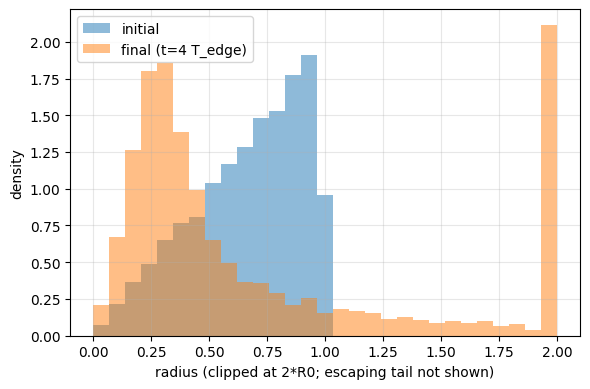

In [7]:
r_initial = np.linalg.norm(pos_t[0], axis=-1)
r_final = np.linalg.norm(pos_t[-1], axis=-1)
percentiles = [50, 90, 99, 100]
print('radius percentiles, initial:', dict(zip(percentiles, np.round(np.percentile(r_initial, percentiles), 3))))
print('radius percentiles, final:  ', dict(zip(percentiles, np.round(np.percentile(r_final, percentiles), 3))))

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 2 * R0, 30)
ax.hist(np.clip(r_initial, 0, 2 * R0), bins=bins, alpha=0.5, label='initial', density=True)
ax.hist(np.clip(r_final, 0, 2 * R0), bins=bins, alpha=0.5, label=f'final (t={n_steps*dt/T_edge:.0f} T_edge)', density=True)
ax.set_xlabel('radius (clipped at 2*R0; escaping tail not shown)'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/galaxy_collapse_radial_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [14]:
frame_stride = 10
frames_pos = pos_t[::frame_stride]
n_frames = len(frames_pos)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('k')
view = 3 * R0
ax.set(xlim=(-view, view), ylim=(-view, view))
ax.set_xticks([]); ax.set_yticks([])
scat = ax.scatter([], [], s=0.1, color='white', alpha=0.7)
text = ax.text(0.02, 0.96, '', color='white', transform=ax.transAxes)

def animate(i):
    scat.set_offsets(frames_pos[i])
    text.set_text(f't = {i * frame_stride * dt:.2f} ({i * frame_stride * dt / T_edge:.1f} T_edge)')
    return scat, text

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
ani.save('media/galaxy_collapse.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/galaxy_collapse.mp4')

saved media/galaxy_collapse.mp4
